# Семинар №1. Численные методы математического анализа в Python

**Курс:** 2 курс  
**Среда:** Jupyter Notebook / Google Colab  
**Ориентировочная продолжительность:** 1 пара  
**Основные библиотеки:** NumPy, Matplotlib, SciPy

> **Студенческая версия.** Ячейки с пометкой `TODO` необходимо заполнить самостоятельно.

---

## Цель семинара

На практике увидеть различие между математической формулой и её численной реализацией, а также освоить базовый цикл вычислительного эксперимента:

1. сформулировать математическую задачу;
2. построить численный алгоритм;
3. реализовать его на Python;
4. проверить результат на известном или эталонном решении;
5. визуализировать погрешность или поведение метода;
6. сформулировать содержательный вывод.

В рамках семинара рассматриваются четыре небольших исследования:

- численное вычисление пределов и потеря точности;
- численное дифференцирование и градиент;
- интерполяция и феномен Рунге;
- численное интегрирование и правило Рунге.

---

## Как работать с блокнотом

Запускайте ячейки **сверху вниз**. Готовые ячейки с визуализациями можно изменять только после того, как получен исходный результат.

В заданиях важно не только получить число или график, но и объяснить:

- что именно вычисляется;
- почему выбранный алгоритм работает;
- откуда может возникнуть погрешность;
- как проверить корректность результата.

Если программа выдаёт `NotImplementedError`, это означает, что соответствующий фрагмент с `TODO` ещё не реализован.

In [2]:
# Подключается NumPy для работы с числами, массивами и математическими функциями
import numpy as np

# Подключается модуль Matplotlib для построения графиков
import matplotlib.pyplot as plt

# Импортируется функция quad для эталонного численного интегрирования
from scipy.integrate import quad

# Настраивается вывод массивов: 8 знаков точности и без лишней экспоненциальной записи
np.set_printoptions(precision=8, suppress=True)

# Устанавливается стандартный размер всех графиков в блокноте
plt.rcParams["figure.figsize"] = (8, 4.5)

# Устанавливается размер шрифта подписей на графиках
plt.rcParams["font.size"] = 12

# Выводится сообщение о готовности среды
print("Среда готова к работе.")

Среда готова к работе.


# 0. Перед началом: что такое численный эксперимент?

В математическом анализе часто рассматриваются **точные** объекты: предел, производная, интеграл, интерполяционный полином.

Компьютер работает иначе:

- числа хранятся с конечной точностью;
- бесконечный процесс необходимо остановить;
- производную приходится заменять конечной разностью;
- интеграл заменяется конечной суммой;
- результат зависит не только от формулы, но и от алгоритма вычисления.

Поэтому корректный численный результат — это не просто «получилось число». Нужно уметь оценить **погрешность**, проверить **устойчивость** и сравнить результат с эталоном.

### Абсолютная погрешность

Если известно эталонное значение $x^*$, то

$$
\Delta = |x - x^*|.
$$

Когда погрешности меняются на несколько порядков, удобно использовать логарифмический масштаб.

# 1. Численное вычисление пределов

## 1.1. Почему правильная формула может давать неправильный численный результат?

Рассмотрим простой пример:

$$
g(t)=\sqrt{1+t}-1,\qquad t\to 0.
$$

При очень малом $t$ числа $\sqrt{1+t}$ и $1$ становятся почти одинаковыми. Их вычитание приводит к **катастрофической отмене**: значащие цифры теряются из-за ограниченной точности представления чисел.

Математически выражение можно переписать, домножив числитель и знаменатель на сопряжённое выражение:

$$
\sqrt{1+t}-1
=
\frac{t}{\sqrt{1+t}+1}.
$$

Обе записи математически эквивалентны, но численно могут вести себя по-разному.

Выполните следующую ячейку и посмотрите, что происходит при уменьшении $t$.

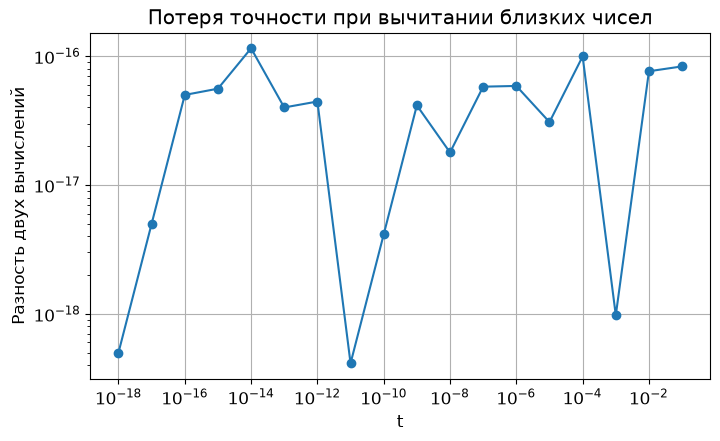

Последние значения:
t=1.0e-14: прямая форма=4.885e-15, устойчивая форма=5.000e-15
t=1.0e-15: прямая форма=4.441e-16, устойчивая форма=5.000e-16
t=1.0e-16: прямая форма=0.000e+00, устойчивая форма=5.000e-17
t=1.0e-17: прямая форма=0.000e+00, устойчивая форма=5.000e-18
t=1.0e-18: прямая форма=0.000e+00, устойчивая форма=5.000e-19


In [3]:
# Создаётся массив значений t: 10^(-1), 10^(-2), ..., 10^(-18).
t = 10.0 ** (-np.arange(1, 19))

# Выражение вычисляется напрямую через вычитание двух близких чисел.
direct = np.sqrt(1 + t) - 1

# То же выражение вычисляется в математически эквивалентной, но более устойчивой форме.
stable = t / (np.sqrt(1 + t) + 1)

# Создаётся новая область для графика.
plt.figure()

# Строится график разности двух способов вычисления в логарифмическом масштабе.
plt.loglog(t, np.abs(direct - stable), marker="o")

# Подписывается горизонтальная ось.
plt.xlabel("t")

# Подписывается вертикальная ось.
plt.ylabel("Разность двух вычислений")

# Задаётся заголовок графика.
plt.title("Потеря точности при вычитании близких чисел")

# Добавляется координатная сетка.
plt.grid(True)

# График выводится на экран.
plt.show()

# Выводится заголовок для нескольких последних численных значений.
print("Последние значения:")

# Одновременно перебираются последние пять значений t и результаты двух формул.
for ti, d, s in zip(t[-5:], direct[-5:], stable[-5:]):
    # Значения выводятся в компактном научном формате.
    print(f"t={ti:.1e}: прямая форма={d:.3e}, устойчивая форма={s:.3e}")

## 1.2. Задание 1. Исследование последовательности

Рассмотрим последовательность

$$
a_n=n\left(\sqrt{n^2+1}-n\right).
$$

Аналитически её предел при $n\to\infty$ равен

$$
\frac{1}{2}.
$$

### Необходимо

1. Реализовать функцию `term_direct(n)`, вычисляющую выражение **в исходном виде**.
2. Преобразовать выражение так, чтобы устранить вычитание близких чисел, и реализовать `term_stable(n)`.
3. Для $n=2^2,2^3,\ldots,2^{28}$ сравнить обе реализации.
4. Построить график абсолютной погрешности относительно $1/2$.
5. Объяснить, почему одна из форм при больших $n$ начинает вести себя неожиданно.

### Подсказка

Используйте тождество

$$
(\sqrt{A}-B)(\sqrt{A}+B)=A-B^2.
$$

Важно: требуется **алгебраически преобразовать исходное выражение**, а не просто вернуть число `0.5`.

In [4]:
# Объявляется функция для вычисления последовательности в исходной форме
def term_direct(n):
    return n * (np.sqrt(n ** 2 + 1) - n)


# Объявляется функция для вычисления той же последовательности в устойчивой форме
def term_stable(n):
    return n / (np.sqrt(n ** 2 + 1) + n)

In [ ]:
# @title Решение задания 1 — функции { display-mode: "form" }
def term_direct(n):
    n = float(n)
    return n * (np.sqrt(n**2 + 1.0) - n)


def term_stable(n):
    n = float(n)
    return n / (np.sqrt(n**2 + 1.0) + n)

Последние пять значений:
n=  16777216: direct=0.5000000000000000, stable=0.4999999999999996
n=  33554432: direct=0.5000000000000000, stable=0.4999999999999999
n=  67108864: direct=0.0000000000000000, stable=0.5000000000000000
n= 134217728: direct=0.0000000000000000, stable=0.5000000000000000
n= 268435456: direct=0.0000000000000000, stable=0.5000000000000000


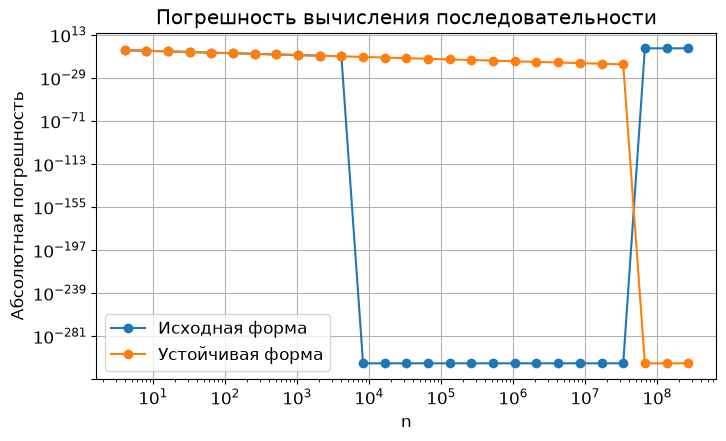

In [5]:
# Создаётся набор значений n: 2^2, 2^3, ..., 2^28
n_values = 2 ** np.arange(2, 29)

# Сохраняется известное предельное значение последовательности
reference = 0.5

# Запускается блок проверки реализованных функци
try:
    # Исходная формула вычисляется для всех значений n и собирается в массив
    direct_values = np.array([term_direct(n) for n in n_values], dtype=float)

    # Устойчивая формула вычисляется для тех же значений n
    stable_values = np.array([term_stable(n) for n in n_values], dtype=float)

    # Вычисляется абсолютная погрешность исходной формулы относительно предела
    direct_error = np.abs(direct_values - reference)

    # Вычисляется абсолютная погрешность устойчивой формулы
    stable_error = np.abs(stable_values - reference)

    # Выводится заголовок для нескольких последних значений
    print("Последние пять значений:")

    # Перебираются последние пять n и соответствующие результаты
    for n, d, s in zip(n_values[-5:], direct_values[-5:], stable_values[-5:]):
        # Значения выводятся с высокой точностью для сравнени
        print(f"n={n:>10d}: direct={d:.16f}, stable={s:.16f}")

    # Создаётся новая область для графика
    plt.figure()

    # Строится погрешность исходной формулы; слишком малые значения заменяются минимальным положительным числом
    plt.loglog(n_values, np.maximum(direct_error, np.finfo(float).tiny), marker="o", label="Исходная форма")

    # Аналогично строится погрешность устойчивой формулы
    plt.loglog(n_values, np.maximum(stable_error, np.finfo(float).tiny), marker="o", label="Устойчивая форма")

    # Подписывается горизонтальная ось
    plt.xlabel("n")

    # Подписывается вертикальная ось
    plt.ylabel("Абсолютная погрешность")

    # Задаётся заголовок график
    plt.title("Погрешность вычисления последовательности")

    # Добавляется сетка
    plt.grid(True)

    # Добавляется легенда с названиями двух кривых
    plt.legend()

    # График выводится на экран
    plt.show()

# Если функции ещё не реализованы, ошибка перехватывается
except NotImplementedError:
    print("Сначала реализуйте term_direct() и term_stable() в предыдущей ячейке.")

### Вывод по заданию 1

В 3–5 предложениях ответьте:

1. Какая из двух форм оказалась устойчивее?
2. Что происходит с исходной формой при очень больших $n$?
3. Почему математически эквивалентные выражения дают разные результаты на компьютере?

**Ваш вывод:**
    "Устойчивая форма" оказывается устойчивее и сохраняет стабильно низкую погрешность на протяжении всего графика. В это же время при очень больших $n$ "Исходная форма" показывает резкий рост погрешности относительно результатов, полученных на отрезке [10^4; 10^7]. Математически эквивалентные выражения дают разные результаты на компьютере из-за отсутствия в "Устойчивой форме" вычитания близких чисел, которое из-за представления чисел с плавающей точкой с конечной точностью приводит к катастрофической отмене.

# 2. Производные и градиенты

## 2.1. От производной к конечной разности

Производная определяется пределом, но на компьютере предел непосредственно не вычисляется.
Одна из наиболее распространённых аппроксимаций — **центральная разность**:

$$
f'(x)\approx\frac{f(x+h)-f(x-h)}{2h}.
$$

Для достаточно гладкой функции её погрешность аппроксимации имеет порядок $O(h^2)$.

Для функции нескольких переменных

$$
f(x_1,\ldots,x_m)
$$

градиент представляет собой вектор частных производных:

$$
\nabla f =
\left(
\frac{\partial f}{\partial x_1},
\ldots,
\frac{\partial f}{\partial x_m}
\right).
$$

Численно каждую компоненту можно вычислить центральной разностью, изменяя только одну координату.

---

## 2.2. Геометрический смысл градиента

Градиент направлен в сторону наиболее быстрого возрастания функции.

Ниже показаны линии уровня функции и направление аналитического градиента в одной точке.

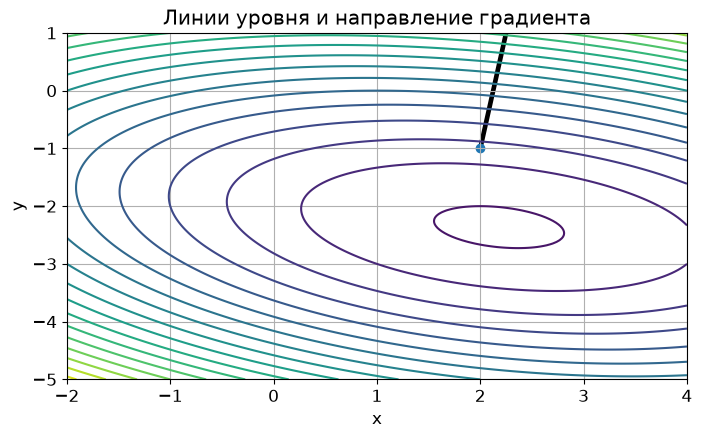

Точка: [ 2. -1.]
Аналитический градиент: [1. 8.]


In [6]:
# Объявляется функция двух переменных, для которой будет показан градиент
def f_visual(x, y):
    # Возвращается значение функции в точке или сразу на сетке точек
    return (x - 1)**2 + 3 * (y + 2)**2 + x * y


# Создаются 200 значений координаты x на заданном отрезке
x_grid = np.linspace(-2, 4, 200)

# Создаются 200 значений координаты y на заданном отрезке
y_grid = np.linspace(-5, 1, 200)

# Из двух одномерных массивов создаётся двумерная координатная сетка
X, Y = np.meshgrid(x_grid, y_grid)

# Функция вычисляется во всех точках этой сетки
Z = f_visual(X, Y)

# Задаётся точка, в которой будет показан градиент
x0 = np.array([2.0, -1.0])

# Аналитически вычисляются две компоненты градиента в выбранной точке
grad0 = np.array([
    # Первая компонента соответствует производной по x
    2 * (x0[0] - 1) + x0[1],
    # Вторая компонента соответствует производной по y
    6 * (x0[1] + 2) + x0[0]
])

# Создаётся новая область для графика
plt.figure()

# Строятся линии уровня функции
plt.contour(X, Y, Z, levels=18)

# В выбранной точке рисуется вектор градиента
plt.quiver(x0[0], x0[1], grad0[0], grad0[1], angles="xy", scale_units="xy", scale=3)

# Сама точка отмечается на графике
plt.scatter([x0[0]], [x0[1]])

# Подписывается ось x
plt.xlabel("x")

# Подписывается ось y
plt.ylabel("y")

# Задаётся заголовок графика
plt.title("Линии уровня и направление градиента")

# Добавляется координатная сетка
plt.grid(True)

# График выводится на экран
plt.show()

# Выводятся координаты выбранной точки
print("Точка:", x0)

# Выводится аналитически вычисленный градиент
print("Аналитический градиент:", grad0)

## 2.3. Задание 2. Численный градиент

Реализуйте функцию

```python
gradient_fd(f, x, h)
```

которая вычисляет градиент функции центральными разностями.

### Требования

- `x` может содержать произвольное число координат;
- для каждой координаты необходимо отдельно вычислить $f(x+h e_i)$ и $f(x-h e_i)$;
- исходный массив `x` нельзя изменять;
- функция должна возвращать массив той же длины, что и `x`.

### Алгоритм

Для каждой координаты $i$:

1. создать копии точки `x_plus` и `x_minus`;
2. увеличить координату `i` в `x_plus` на `h`;
3. уменьшить координату `i` в `x_minus` на `h`;
4. вычислить соответствующую компоненту градиента.

После реализации исследуйте, как ошибка зависит от шага $h$.

In [54]:
# Объявляется функция для численного вычисления градиента методом конечных разностей
def gradient_fd(f, x, h=1e-5):
    point = np.asarray(x, dtype=float)

    n = len(point)
    shift = np.eye(n) * h

    point_plus = point + shift
    point_minus = point - shift

    return np.array([(f(point_plus[i]) - f(point_minus[i])) / (2 * h) for i in range(n)])
    

In [39]:
# @title Решение задания 2 — gradient_fd { display-mode: "form" }
def gradient_fd(f, x, h=1e-5):
    x = np.asarray(x, dtype=float)
    grad = np.zeros_like(x)

    for i in range(len(x)):
        x_plus = x.copy()
        x_minus = x.copy()

        x_plus[i] += h
        x_minus[i] -= h

        grad[i] = (f(x_plus) - f(x_minus)) / (2.0 * h)

    return grad

Проверка на квадратичной функции:
Численный градиент: [1. 8.]
Аналитический градиент: [1. 8.]
Норма ошибки: 5.2817495400825455e-11

Минимальная ошибка в эксперименте: 5.297e-11
Соответствующий шаг h: 1.0e-05


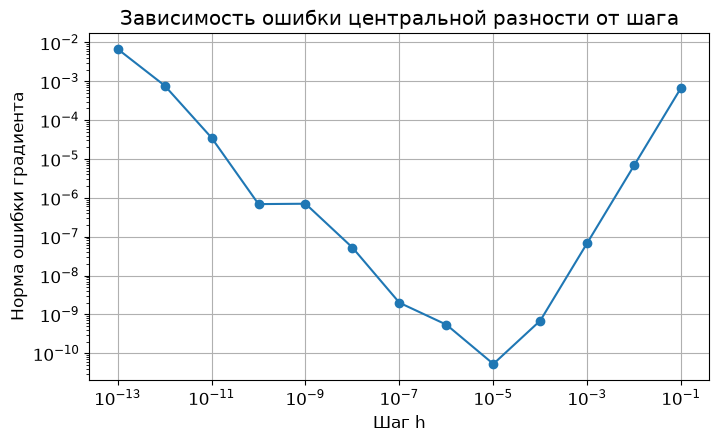

In [55]:
# Задаётся тестовая функция двух переменных в компактной форме lambda
f_quad = lambda x: (x[0] - 1)**2 + 3 * (x[1] + 2)**2 + x[0] * x[1]


# Объявляется функция, возвращающая точный градиент f_quad
def grad_quad(x):
    # Возвращается массив из двух аналитически вычисленных производных
    return np.array([
        # Производная по первой координате
        2 * (x[0] - 1) + x[1],
        # Производная по второй координате
        6 * (x[1] + 2) + x[0]
    ])


# Добавляется нелинейная функция, чтобы нагляднее увидеть зависимость ошибки от шага h
f_test = lambda x: np.sin(x[0]) + (x[0] - 1)**2 + 3 * (x[1] + 2)**2 + x[0] * x[1]


# Объявляется функция с точным градиентом нелинейной тестовой функции
def grad_test(x):
    # Возвращается массив аналитических частных производных
    return np.array([
        # Производная по первой координате
        np.cos(x[0]) + 2 * (x[0] - 1) + x[1],
        # Производная по второй координате
        6 * (x[1] + 2) + x[0]
    ])


# Выбирается точка, в которой будут сравниваться градиенты
point = np.array([2.0, -1.0])

# Запускается проверка пользовательской реализации
try:
    # Численный градиент вычисляется с заданным шагом
    numeric = gradient_fd(f_quad, point, h=1e-5)

    # Аналитический градиент вычисляется для той же точки
    exact = grad_quad(point)

    # Выводится заголовок проверки
    print("Проверка на квадратичной функции:")

    # Выводится численный результат
    print("Численный градиент:", numeric)

    # Выводится точный результат
    print("Аналитический градиент:", exact)

    # Вычисляется длина вектора ошибки между двумя градиентами
    print("Норма ошибки:", np.linalg.norm(numeric - exact))

    # Создаётся набор шагов h от 10^-1 до 10^-13
    h_values = 10.0 ** (-np.arange(1, 14))

    # Для тестовой функции вычисляется точный градиент
    exact_test = grad_test(point)

    # Для каждого h вычисляется норма ошибки численного градиента
    errors = np.array([
        # Сравнивается численный и аналитический градиент
        np.linalg.norm(gradient_fd(f_test, point, h=h) - exact_test)
        # Перебираются все заданные значения шага
        for h in h_values
    ])

    # Находится индекс минимальной ошибки
    best_index = np.argmin(errors)

    # Выводится пустая строка для читаемости
    print()

    # Выводится минимальная найденная ошибка
    print(f"Минимальная ошибка в эксперименте: {errors[best_index]:.3e}")

    # Выводится шаг, при котором получена эта ошибка
    print(f"Соответствующий шаг h: {h_values[best_index]:.1e}")

    # Создаётся новая область для графика
    plt.figure()

    # Строится зависимость ошибки от шага в логарифмическом масштабе
    plt.loglog(h_values, errors, marker="o")

    # Подписывается горизонтальная ось
    plt.xlabel("Шаг h")

    # Подписывается вертикальная ось
    plt.ylabel("Норма ошибки градиента")

    # Задаётся заголовок графика
    plt.title("Зависимость ошибки центральной разности от шага")

    # Добавляется сетка
    plt.grid(True)

    # График выводится на экран
    plt.show()

# Если gradient_fd ещё не реализована, ошибка перехватывается
except NotImplementedError:
    # Выводится подсказка о необходимом предыдущем шаге
    print("Сначала реализуйте gradient_fd() в предыдущей ячейке.")

### Вывод по заданию 2

Ответьте в 3–5 предложениях:

1. Почему уменьшение $h$ сначала улучшает результат?
2. Почему при слишком малом $h$ ошибка снова может увеличиваться?
3. Почему нельзя выбирать шаг по принципу «чем меньше, тем лучше»?

**Ваш вывод:**
        Изначально уменьшение $h$ уменьшает ошибку аппроксимации (которая O(h^2)), поэтому результат получается более точным. При дальнейшем уменьшении шага мы сталкиваемся с проблемой катастрафической отмены из-за вычитания близких чисел, что приводит к закономерному увеличению погрешности. Именно поэтому нельзя выбирать шаг по принципу "чем меньше, тем лучше", лучше всего искать точку оптимума, где ошибка аппроксимации будет минимальна.

# 3. Интерполяция

## 3.1. Постановка задачи

Пусть известны значения функции в узлах

$$
(x_0,y_0),\ldots,(x_n,y_n).
$$

**Интерполяционный полином** должен проходить точно через все заданные точки.

Одна из удобных форм — полином Ньютона:

$$
P_n(x)=c_0+c_1(x-x_0)+c_2(x-x_0)(x-x_1)+\ldots
$$

Коэффициенты $c_k$ определяются при помощи **разделённых разностей**.

Форма Ньютона удобна тем, что после вычисления коэффициентов полином можно эффективно
вычислять вложенной схемой, аналогичной схеме Горнера.

---

## 3.2. Почему расположение узлов имеет значение?

Для функции Рунге

$$
f(x)=\frac{1}{1+25x^2}, \qquad x\in[-1,1]
$$

интерполяция полиномом высокой степени на равномерной сетке может приводить к сильным
колебаниям около концов отрезка. Это явление называют **феноменом Рунге**.

Один из способов уменьшить эффект — использовать узлы Чебышёва, которые расположены
плотнее у краёв интервала.

Сначала сравните только расположение узлов.

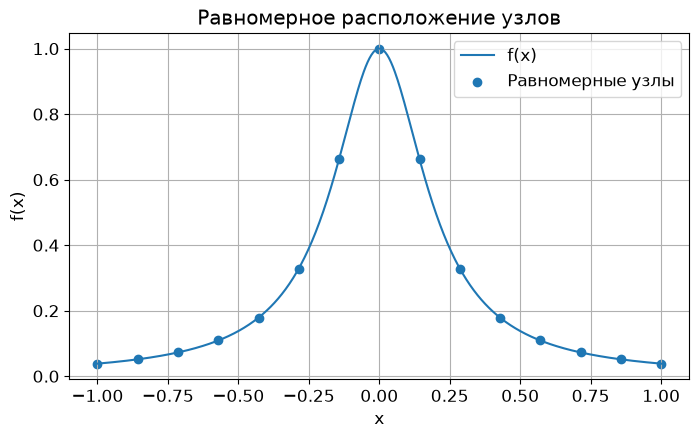

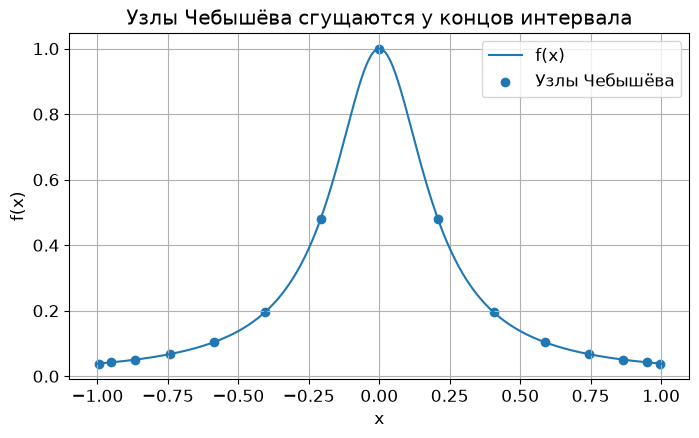

In [56]:
# Задаётся функция Рунге
runge = lambda x: 1 / (1 + 25 * x**2)

# Задаётся количество узлов интерполяции
n_nodes = 15

# Создаются равномерно расположенные узлы на отрезке [-1, 1]
x_equal = np.linspace(-1, 1, n_nodes)

# Создаются целые индексы узлов от 0 до n_nodes - 1
k = np.arange(n_nodes)

# По формуле вычисляются узлы Чебышёва
x_cheb = np.cos((2 * k + 1) * np.pi / (2 * n_nodes))

# Узлы Чебышёва сортируются слева направо
x_cheb = np.sort(x_cheb)

# Создаётся плотная сетка для гладкого отображения исходной функции
x_dense = np.linspace(-1, 1, 600)

# Создаётся первая область для графика
plt.figure()

# Строится график исходной функции
plt.plot(x_dense, runge(x_dense), label="f(x)")

# На график наносятся равномерные узлы
plt.scatter(x_equal, runge(x_equal), label="Равномерные узлы")

# Подписывается ось x
plt.xlabel("x")

# Подписывается ось y
plt.ylabel("f(x)")

# Задаётся заголовок
plt.title("Равномерное расположение узлов")

# Добавляется сетка
plt.grid(True)

# Добавляется легенда
plt.legend()

# Первый график выводится на экран
plt.show()

# Создаётся вторая область для графика
plt.figure()

# Снова строится исходная функция
plt.plot(x_dense, runge(x_dense), label="f(x)")

# На график наносятся узлы Чебышёва
plt.scatter(x_cheb, runge(x_cheb), label="Узлы Чебышёва")

# Подписывается ось x
plt.xlabel("x")

# Подписывается ось y
plt.ylabel("f(x)")

# Задаётся заголовок
plt.title("Узлы Чебышёва сгущаются у концов интервала")

# Добавляется сетка
plt.grid(True)

# Добавляется легенда
plt.legend()

# Второй график выводится на экран
plt.show()

## 3.3. Задание 3. Полином Ньютона и феномен Рунге

Реализуйте две функции:

### `divided_differences(x, y)`

Функция должна вернуть коэффициенты $c_0,\ldots,c_n$ полинома Ньютона.

Можно использовать следующую схему:

1. скопировать значения `y` в массив коэффициентов;
2. последовательно вычислять разделённые разности 1-го, 2-го и следующих порядков;
3. не изменять исходные массивы `x` и `y`.

### `newton_value(x_nodes, coef, x)`

Функция должна вычислять значение полинома Ньютона в одной точке или сразу в массиве точек.

Рекомендуется использовать вложенную схему:

$$
P_n(x)=c_0+(x-x_0)\left[c_1+(x-x_1)\left[c_2+\ldots\right]\right].
$$

После реализации:

1. интерполируйте функцию Рунге по 15 равномерным узлам;
2. повторите эксперимент для 15 узлов Чебышёва;
3. постройте графики исходной функции и двух интерполяционных полиномов;
4. сравните максимальную абсолютную ошибку.

Формула разделенных разностей задается рекурентно
\begin{cases}
  f[x_i] = y_i, & \text{для } k = 0 \\[10pt]
  f[x_i, x_{i+1}, \dots, x_{i+k}] = \frac{f[x_{i+1}, \dots, x_{i+k}] - f[x_i, \dots, x_{i+k-1}]}{x_{i+k} - x_i}, & \text{для } k \ge 1
\end{cases}

Формула полинома Ньютона (вложенная схема) в рекурентной форме
R_i = \begin{cases} 
  c_n, & \text{при } i = n \\[6pt]
  c_i + (x - x_i) \cdot R_{i+1}, & \text{при } i = n-1, n-2, \dots, 0 
\end{cases}


In [89]:
# Объявляется функция для вычисления коэффициентов полинома Ньютона
from functools import lru_cache

@lru_cache(maxsize=None)
def divided_difference(x: tuple, y: tuple):
    if len(x) == 1:
        return y[0]

    return (divided_difference(x[1:], y[1:]) - divided_difference(x[:-1], y[:-1])) / (x[-1] - x[0])

def divided_differences(x, y):
    if x.ndim != 1 or y.ndim != 1 or len(x) != len(y):
        raise ValueError("x и y должны быть одномерными массивами одинаковой длины")
    if len(np.unique(x)) != len(x):
        raise ValueError("Узлы интерполяции должны быть различными")

    return np.array([divided_difference(tuple(x[:i]), tuple(y[:i])) for i in range(1, len(x) + 1)])

# Объявляется функция для вычисления значения готового полинома Ньютона
def newton_value(x_nodes, coef, x):
    if len(x_nodes) != len(coef):
        raise ValueError("Количество узлов и коэффициентов должно совпадать")

    n = len(coef) - 1
    result = coef[n]
    
    for i in range(n - 1, -1, -1):
        result = coef[i] + (x - x_nodes[i]) * result
        
    return result

In [90]:
# @title Решение задания 3 — интерполяция Ньютона { display-mode: "form" }
def divided_differences(x, y):
    x = np.asarray(x, dtype=float)
    coef = np.asarray(y, dtype=float).copy()

    if x.ndim != 1 or coef.ndim != 1 or len(x) != len(coef):
        raise ValueError("x и y должны быть одномерными массивами одинаковой длины")
    if len(np.unique(x)) != len(x):
        raise ValueError("Узлы интерполяции должны быть различными")

    n = len(x)
    for order in range(1, n):
        coef[order:n] = (
            coef[order:n] - coef[order - 1:n - 1]
        ) / (
            x[order:n] - x[:n - order]
        )

    return coef


def newton_value(x_nodes, coef, x):
    x_nodes = np.asarray(x_nodes, dtype=float)
    coef = np.asarray(coef, dtype=float)
    x = np.asarray(x, dtype=float)

    if len(x_nodes) != len(coef):
        raise ValueError("Количество узлов и коэффициентов должно совпадать")

    value = np.zeros_like(x, dtype=float) + coef[-1]
    for i in range(len(coef) - 2, -1, -1):
        value = coef[i] + (x - x_nodes[i]) * value

    return value

Проверка на функции x^2:
P(1.5) = 2.25 ; ожидается 2.25

Максимальная ошибка, равномерные узлы: 7.192324e+00
Максимальная ошибка, узлы Чебышёва:   4.660098e-02


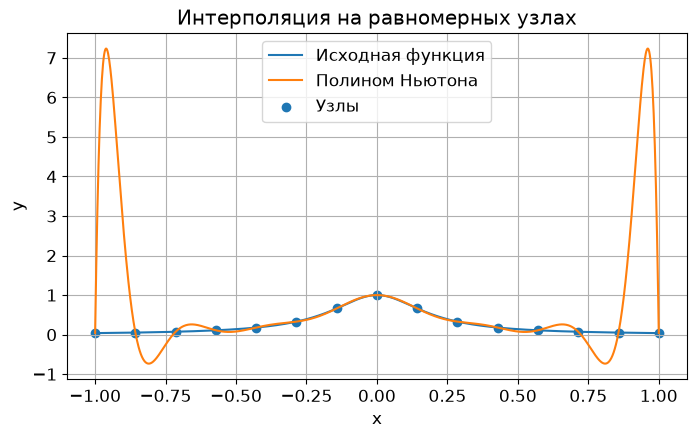

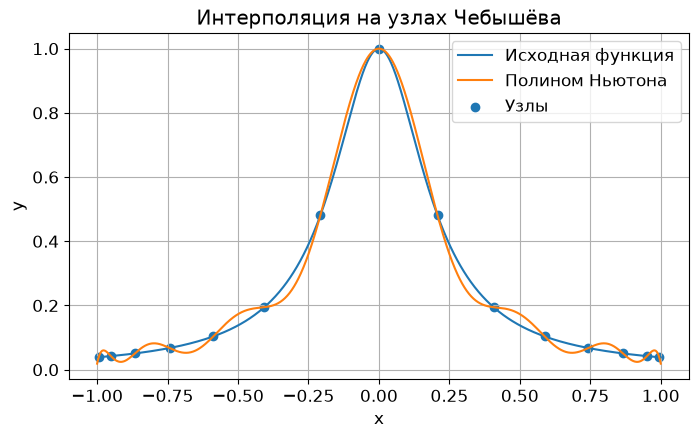

In [91]:
# Запускается проверка реализованных функций интерполяции
try:
    # Создаются три тестовых узла
    x_test = np.array([0.0, 1.0, 2.0])

    # В узлах вычисляются значения функции x^2
    y_test = x_test**2

    # По тестовым данным вычисляются коэффициенты полинома Ньютона
    coef_test = divided_differences(x_test, y_test)

    # Полином вычисляется в промежуточной точке x = 1.5
    check_value = newton_value(x_test, coef_test, 1.5)

    # Выводится заголовок теста
    print("Проверка на функции x^2:")

    # Полученный результат сравнивается с ожидаемым значением 2.25
    print("P(1.5) =", float(check_value), "; ожидается 2.25")

    # Задаётся функция Рунге для основного эксперимента
    runge = lambda x: 1 / (1 + 25 * x**2)

    # Задаётся количество интерполяционных узлов
    n_nodes = 15

    # Создаётся плотная сетка для оценки полинома между узлами
    x_dense = np.linspace(-1, 1, 1000)

    # На плотной сетке вычисляются истинные значения функции
    y_true = runge(x_dense)

    # Создаются равномерные узлы
    x_equal = np.linspace(-1, 1, n_nodes)

    # В равномерных узлах вычисляются значения функции
    y_equal = runge(x_equal)

    # Вычисляются коэффициенты полинома Ньютона для равномерных узлов
    coef_equal = divided_differences(x_equal, y_equal)

    # Полином вычисляется на плотной сетке
    p_equal = newton_value(x_equal, coef_equal, x_dense)

    # Создаются индексы для формулы узлов Чебышёва
    k = np.arange(n_nodes)

    # Вычисляются узлы Чебышёва
    x_cheb = np.cos((2 * k + 1) * np.pi / (2 * n_nodes))

    # Узлы сортируются слева направо
    x_cheb = np.sort(x_cheb)

    # В узлах Чебышёва вычисляются значения функции
    y_cheb = runge(x_cheb)

    # Вычисляются коэффициенты полинома Ньютона для узлов Чебышёва
    coef_cheb = divided_differences(x_cheb, y_cheb)

    # Полином вычисляется на той же плотной сетке
    p_cheb = newton_value(x_cheb, coef_cheb, x_dense)

    # Находится максимальная ошибка для равномерных узлов
    error_equal = np.max(np.abs(p_equal - y_true))

    # Находится максимальная ошибка для узлов Чебышёва
    error_cheb = np.max(np.abs(p_cheb - y_true))

    # Выводится пустая строка для разделения результатов
    print()

    # Выводится максимальная ошибка для равномерных узлов
    print(f"Максимальная ошибка, равномерные узлы: {error_equal:.6e}")

    # Выводится максимальная ошибка для узлов Чебышёва
    print(f"Максимальная ошибка, узлы Чебышёва:   {error_cheb:.6e}")

    # Создаётся график интерполяции на равномерных узлах
    plt.figure()

    # Строится исходная функция
    plt.plot(x_dense, y_true, label="Исходная функция")

    # Строится интерполяционный полином
    plt.plot(x_dense, p_equal, label="Полином Ньютона")

    # На график наносятся исходные узлы
    plt.scatter(x_equal, y_equal, label="Узлы")

    # Подписывается ось x
    plt.xlabel("x")

    # Подписывается ось y
    plt.ylabel("y")

    # Задаётся заголовок
    plt.title("Интерполяция на равномерных узлах")

    # Добавляется сетка
    plt.grid(True)

    # Добавляется легенда
    plt.legend()

    # Первый график выводится на экран
    plt.show()

    # Создаётся график интерполяции на узлах Чебышёва
    plt.figure()

    # Строится исходная функция
    plt.plot(x_dense, y_true, label="Исходная функция")

    # Строится интерполяционный полином
    plt.plot(x_dense, p_cheb, label="Полином Ньютона")

    # На график наносятся узлы Чебышёва
    plt.scatter(x_cheb, y_cheb, label="Узлы")

    # Подписывается ось x
    plt.xlabel("x")

    # Подписывается ось y
    plt.ylabel("y")

    # Задаётся заголовок
    plt.title("Интерполяция на узлах Чебышёва")

    # Добавляется сетка
    plt.grid(True)

    # Добавляется легенда
    plt.legend()

    # Второй график выводится на экран
    plt.show()

# Если функции ещё не реализованы, ошибка перехватывается
except NotImplementedError:
    # Выводится подсказка о необходимых предыдущих действиях
    print("Сначала реализуйте divided_differences() и newton_value().")

### Вывод по заданию 3

Ответьте:

1. Проходит ли интерполяционный полином через все заданные узлы?
2. Где возникают наибольшие колебания при равномерных узлах?
3. Как изменяется результат при использовании узлов Чебышёва?
4. Почему увеличение числа узлов не всегда автоматически улучшает интерполяцию?

**Ваш вывод:**
1. Интерполяционный полином проходит черезз все заданные узлы, потому что полином Ньютона устроен таким образом, что в узлах его значения точно совпадают со значениями исходной функции.
2. Нибольшие колебания при равномерных узлах возникают на краях интервала (явление Рунге)
3. При использовании узлов Чебышева результат сильно улучшается; сгущение узлов у краев интервала позволяет избвиться от колебаний и увеличить точность аппроксимации
4. При увеличении числа равномерных узлов не улучшает интерполяцию, потому что при этом возрастает степень полинома, что ведет к увеличению амплитуды колебаний на краях интервала.

# 4. Численное интегрирование

## 4.1. Идея квадратурной формулы

Определённый интеграл

$$
I=\int_a^b f(x)\,dx
$$

можно интерпретировать как площадь с учётом знака. В численном методе непрерывная функция
заменяется более простой моделью на конечном числе подынтервалов.

В **составной формуле трапеций** отрезок $[a,b]$ разбивается на $n$ частей:

$$
h=\frac{b-a}{n}.
$$

Тогда

$$
T_n =
h\left[
\frac{f(x_0)}{2}
+\sum_{i=1}^{n-1}f(x_i)
+\frac{f(x_n)}{2}
\right].
$$

Для достаточно гладкой функции погрешность имеет порядок $O(h^2)$.

Ниже показано, как функция заменяется ломаной при небольшом числе разбиений.

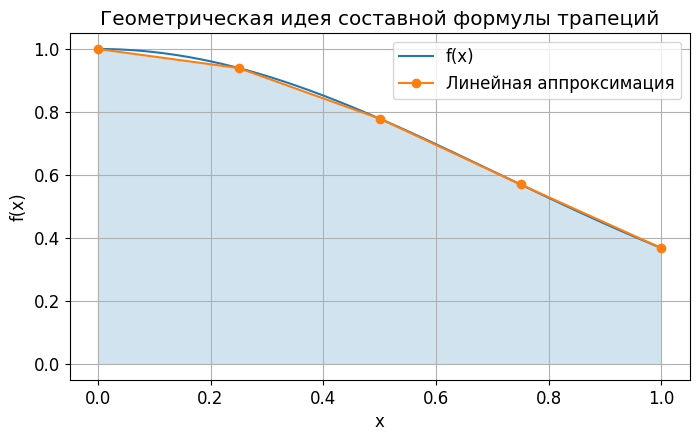

In [14]:
# Задаётся функция, интеграл которой будет приближён методом трапеций
f_demo = lambda x: np.exp(-x**2)

# Задаются левая граница, правая граница и число подынтервалов
a_demo, b_demo, n_demo = 0.0, 1.0, 4

# Создаётся плотная сетка для гладкого графика исходной функции
x_dense = np.linspace(a_demo, b_demo, 400)

# Создаются узлы разбиения, используемые методом трапеций
x_nodes = np.linspace(a_demo, b_demo, n_demo + 1)

# Создаётся новая область для графика
plt.figure()

# Строится исходная функция
plt.plot(x_dense, f_demo(x_dense), label="f(x)")

# Узлы соединяются прямыми отрезками, образующими верхние стороны трапеций
plt.plot(x_nodes, f_demo(x_nodes), marker="o", label="Линейная аппроксимация")

# Закрашивается область под линейной аппроксимацией
plt.fill_between(x_nodes, 0, f_demo(x_nodes), alpha=0.2)

# Подписывается ось x
plt.xlabel("x")

# Подписывается ось y
plt.ylabel("f(x)")

# Задаётся заголовок графика
plt.title("Геометрическая идея составной формулы трапеций")

# Добавляется сетка
plt.grid(True)

# Добавляется легенда
plt.legend()

# График выводится на экран
plt.show()

## 4.2. Как понять, достаточно ли разбиений?

Если точное значение интеграла неизвестно, можно сравнить два последовательных приближения:
$T_n$ и $T_{2n}$.

Для метода порядка $p$ правило Рунге даёт оценку:

$$
R \approx \frac{|T_{2n}-T_n|}{2^p-1}.
$$

У формулы трапеций $p=2$, поэтому

$$
R \approx \frac{|T_{2n}-T_n|}{3}.
$$

Адаптивный алгоритм:

1. вычислить $T_n$;
2. удвоить число разбиений;
3. вычислить $T_{2n}$;
4. оценить погрешность по правилу Рунге;
5. если оценка больше `eps`, снова удвоить $n$;
6. иначе завершить вычисления.

## 4.3. Задание 4. Адаптивная формула трапеций

Реализуйте:

### `trapezoid_rule(f, a, b, n)`

Функция должна вычислять составную формулу трапеций.

### `adaptive_trapezoid(f, a, b, eps, max_refinements)`

Функция должна:

- начинать с небольшого числа разбиений;
- на каждой итерации удваивать `n`;
- использовать правило Рунге для метода порядка 2;
- завершать вычисления, когда оценка погрешности меньше `eps`;
- возвращать три значения:
  1. приближённый интеграл;
  2. число разбиений;
  3. последнюю оценку погрешности по правилу Рунге.

Проверьте алгоритм для

$$
f(x)=e^{-x^2},\qquad x\in[0,1].
$$

Для эталонной проверки используйте `scipy.integrate.quad`.

In [97]:
# Объявляется функция для вычисления интеграла составной формулой трапеций
def trapezoid_rule(f, a, b, n):
    if n < 1:
        raise ValueError("n должно быть положительным, больше 1")
    if b <= a:
        raise ValueError("Должно выполняться b > a")
    partition = np.linspace(a, b, n + 1)
    results = f(partition)
    h = (b - a) / n
    
    return h * (results[0] / 2 + np.sum(results[1:-1]) + results[-1] / 2)


# Объявляется функция, автоматически уточняющая результат до заданной точности
def adaptive_trapezoid(f, a, b, eps=1e-8, max_refinements=20):
    if eps <= 0:
        raise ValueError("eps должно быть положительным")

    n = 2
    previous = trapezoid_rule(f, a, b, n)

    for _ in range(max_refinements):
        n *= 2
        current = trapezoid_rule(f, a, b, n)

        r = np.abs(current - previous) / 3

        if r <= eps:
            return current, n, r

        previous = current
    else:
        raise RuntimeError(f"Не удалось достичь заданной точности за {max_refinements} раундов")

In [95]:
# @title Решение задания 4 — квадратуры { display-mode: "form" }
def trapezoid_rule(f, a, b, n):
    if n < 1:
        raise ValueError("n должно быть положительным")
    if b <= a:
        raise ValueError("Должно выполняться b > a")

    x = np.linspace(a, b, n + 1)
    y = np.asarray(f(x), dtype=float)
    h = (b - a) / n

    return h * (0.5 * y[0] + np.sum(y[1:-1]) + 0.5 * y[-1])


def adaptive_trapezoid(f, a, b, eps=1e-8, max_refinements=20):
    if eps <= 0:
        raise ValueError("eps должно быть положительным")

    n = 1
    previous = trapezoid_rule(f, a, b, n)

    for _ in range(max_refinements):
        n *= 2
        current = trapezoid_rule(f, a, b, n)
        runge_error = abs(current - previous) / 3.0

        if runge_error < eps:
            return current, n, runge_error

        previous = current

    raise RuntimeError("Требуемая точность не достигнута")

Собственный алгоритм: 0.746824129158
Число разбиений:      4096
Оценка Рунге:         3.655e-09
scipy.integrate.quad: 0.746824132812
Абсолютная ошибка:    3.655e-09


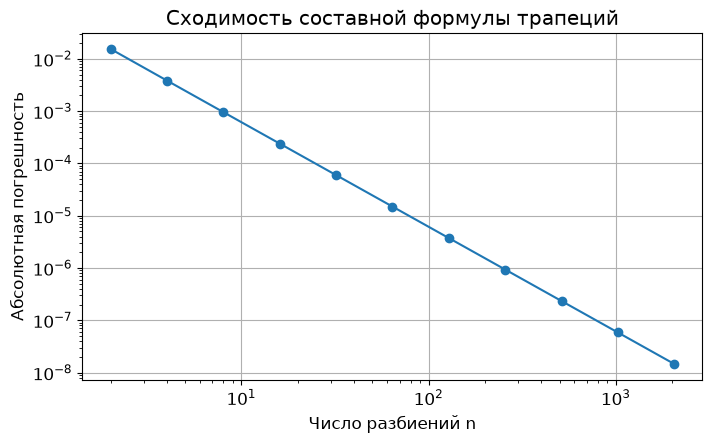

In [98]:
# Задаётся функция, интеграл которой требуется вычислить
f = lambda x: np.exp(-x**2)

# Запускается проверка собственной реализации
try:
    # Адаптивный алгоритм возвращает значение интеграла, число разбиений и оценку ошибки
    value, n_used, runge_error = adaptive_trapezoid(
        # Передаётся функция и границы интегрирования
        f, 0.0, 1.0, eps=1e-8, max_refinements=20
    )

    # С помощью SciPy вычисляется эталонное значение интеграла и внутренняя оценка ошибки
    reference, reference_error = quad(lambda x: np.exp(-x**2), 0.0, 1.0)

    # Вычисляется фактическое отличие собственного результата от эталона
    absolute_error = abs(value - reference)

    # Выводится результат собственной реализации
    print(f"Собственный алгоритм: {value:.12f}")

    # Выводится использованное число разбиений
    print(f"Число разбиений:      {n_used}")

    # Выводится оценка ошибки по правилу Рунге
    print(f"Оценка Рунге:         {runge_error:.3e}")

    # Выводится эталонное значение SciPy
    print(f"scipy.integrate.quad: {reference:.12f}")

    # Выводится реальная абсолютная ошибка относительно эталона
    print(f"Абсолютная ошибка:    {absolute_error:.3e}")

    # Создаётся последовательность числа разбиений: 2, 4, 8, ..., 2048
    n_values = 2 ** np.arange(1, 12)

    # Для каждого числа разбиений вычисляется абсолютная ошибка метода трапеций
    errors = np.array([
        # Собственный результат сравнивается с эталонным значением
        abs(trapezoid_rule(f, 0.0, 1.0, int(n)) - reference)
        # Перебираются все заданные значения n
        for n in n_values
    ])

    # Создаётся новая область для графика
    plt.figure()

    # Строится зависимость ошибки от числа разбиений в логарифмическом масштабе
    plt.loglog(n_values, errors, marker="o")

    # Подписывается горизонтальная ось
    plt.xlabel("Число разбиений n")

    # Подписывается вертикальная ось
    plt.ylabel("Абсолютная погрешность")

    # Задаётся заголовок графика
    plt.title("Сходимость составной формулы трапеций")

    # Добавляется сетка
    plt.grid(True)

    # График выводится на экран
    plt.show()

# Если функции ещё не реализованы, ошибка перехватывается
except NotImplementedError:
    # Выводится сообщение о необходимости сначала заполнить предыдущую ячейку
    print("Сначала реализуйте trapezoid_rule() и adaptive_trapezoid().")

### Вывод по заданию 4

Ответьте:

1. Как меняется ошибка при увеличении числа разбиений?
2. Для чего в адаптивном алгоритме используется правило Рунге?
3. Почему сравнение с `scipy.integrate.quad` полезно, даже если собственный алгоритм уже работает?
4. Совпадает ли оценка Рунге с истинной ошибкой точно или является приближённой оценкой?

**Ваш вывод:**
1. При увеличении числа разбиений абсолютнаяя погрешность уменьшается.
2. Правило Рунге в адаптивном алгоритме используется для оценки погрешности без знания эталонного значения интегралла.
3. Сравнение полезно, т.к. позволяет просто оценить реальную производительность и точность реализованного алгоритма, в то время как теоретическая оценка может быть математически сложна.
4. Оценка Рунге является лишь приближенной оценкой, т.к. в основе ее лежит предположение о том, что истинная ошибка пропорциональна h^p (где p - порядок метода), а вклад членов высшего порядка принебрижимо мал. Несмотря на это оценка остается довольно точной при мелком шаге и в конкретном случае полностью совпадает с абсолютной величиной ошибки.

# 5. Итог семинара

Заполните краткий итоговый вывод.

### 1. Численная устойчивость

Почему две математически эквивалентные формулы могут иметь различную точность на компьютере?

**Ответ:** Из-за явления катастрофической отмены при вычитании близких чисел.

### 2. Численное дифференцирование

Почему шаг конечной разности нельзя уменьшать неограниченно?

**Ответ:** Потому что существует точка оптимума, после прохождения которой в числителе формулы центральных разностей начинается вычитание близких чисел, что приводит к катастрофической отмене и потери точности. 

### 3. Интерполяция

Почему расположение узлов может оказаться важнее простого увеличения их количества?

**Ответ:** При рассмотрении полинома Ньютона простое увеличение количества узлов ведет к повышению его степени, что приводит к увеличению амплитуды колебаний на краях интервала (феномен Рунге). Именно поэтому на концах интервалов узлы лучше сгущать

### 4. Численное интегрирование

Как оценить точность результата, если точное значение интеграла заранее неизвестно?

**Ответ:** При помоще оценки Рунге, которая позволяет сравнивать погрешности результатов, полученных с шагами отличающимися в 2 раза

---

# 6. Вопросы для самопроверки

1. Что называют катастрофической отменой?
2. Что такое машинная точность? (макс. точность хранения чисел с плавающей точкой, минимальное $epsilon$: 1 + $epsilon$ != 1)
3. В чём отличие аналитической производной от её конечно-разностной аппроксимации?
4. Что показывает градиент функции нескольких переменных?
5. Чем интерполяция отличается от аппроксимации? (интерполяция -- это проведение кривой точно через все имеющиеся точки, а аппроксимация -- это нахождение кривой, которая проходит рядом с точками, наиболее точно описывая их тенденцию)
6. Что такое феномен Рунге?
7. Почему узлы Чебышёва сгущаются около концов отрезка? (это проекции на горизонтальную ось точек, равномерно распределенных по полуокружности)
8. Каков порядок точности составной формулы трапеций? ( O(h^2) )
9. В чём идея правила Рунге?
10. Зачем собственную реализацию сравнивать с NumPy/SciPy? (валидация)

# 7. Дополнительные задания

Если основная часть выполнена раньше окончания занятия:

1. Найдите первое значение $n=2^k$, при котором исходная формула из задания 1 перестаёт
   давать разумный результат. Объясните наблюдение.
2. Для численного градиента найдите значение $h$, при котором ошибка минимальна.
3. Повторите интерполяционный эксперимент для 21 и 25 узлов.
4. Измените точность `eps` адаптивного интегрирования на $10^{-4}$, $10^{-6}$,
   $10^{-10}$ и сравните требуемое число разбиений.